# Santa Claude's "Simulated Annealing"

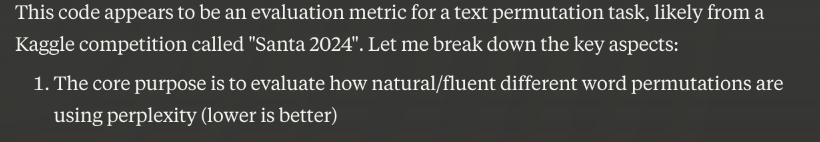


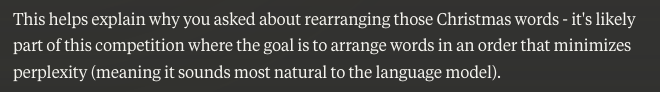


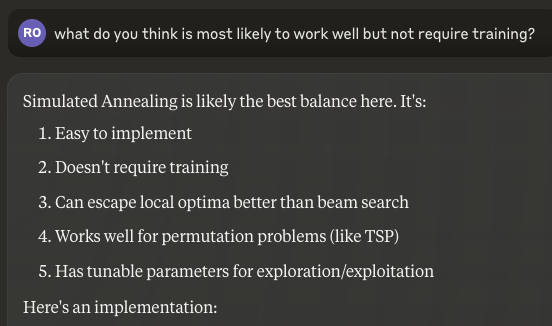

Starting with high temperature, our `math.exp(-delta/temp)` formula makes the algorithm adventurous - willing to accept word arrangements that score 20% worse than current best. As temperature drops, this same formula makes it exponentially pickier, helping escape local minimums while gradually zeroing in on better sequences.

If we encounter invalid arrangements (NaN scores), we simply skip them and keep trying different word swaps. The algorithm tests and refines until it discovers increasingly natural-sounding word combinations, guided by the language model's perplexity scores.

## This notebook imports the prior version of its submission.csv for further optimization...
* Dataset at https://www.kaggle.com/datasets/richolson/santa-claude-output
* So maybe the score just goes up and up?
* Adjusting optimizer parameters (reducing temperature) may be helpful as starting point's score improves...

## This version of the notebook is setup to do a quick run...
* Should run in maybe 20 minutes...
* May not run long enough to find any improvements since we are already scoring pretty well...
* Try increasing "steps_per_temp" if you want to do a longer run
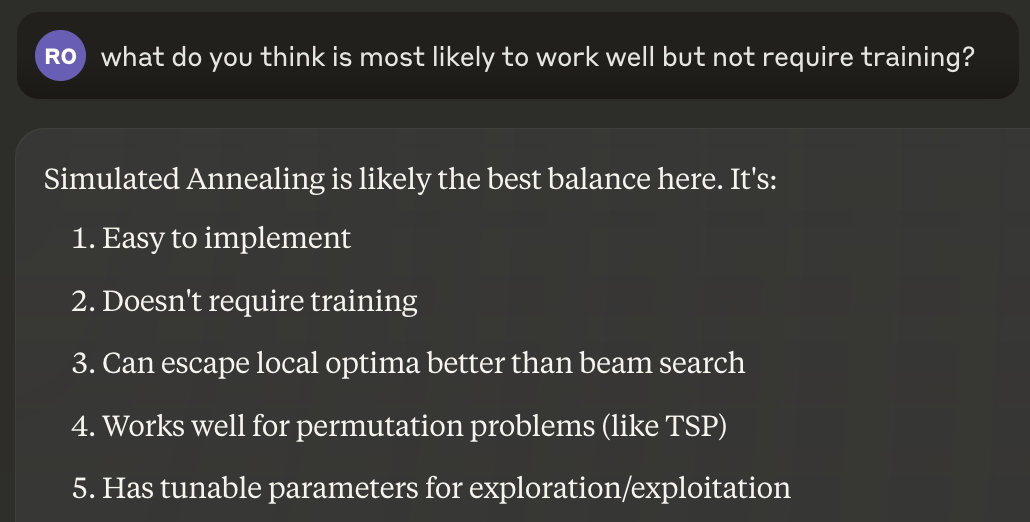
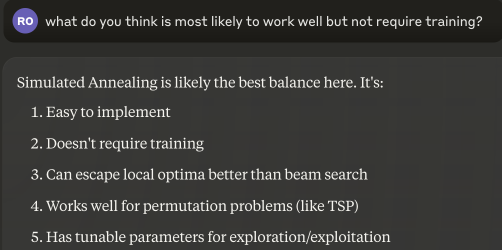
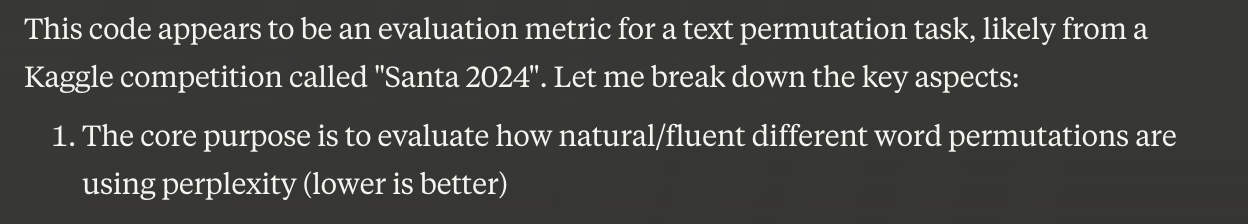

In [ ]:
print("notebook started..")
!pip install -q -U transformers --no-index --find-links /kaggle/input/hf-libraries/transformers
!pip install -q -U accelerate --no-index --find-links /kaggle/input/hf-libraries/accelerate
!pip install -q -U bitsandbytes --no-index --find-links /kaggle/input/hf-libraries/bitsandbytes
print("pip installs done!")

import numpy as np
import pandas as pd
import random
import math

# Load scorer from https://www.kaggle.com/code/metric/santa-2024-metric

In [ ]:
from metric import PerplexityCalculator

#gemma-2-9b (competition scoring metric)
scorer = PerplexityCalculator('/kaggle/input/gemma-2/transformers/gemma-2-9b/2')

# Let's reload our prior submission.csv and optimize from that!!!

In [ ]:
# Set to false to do a "clean" run
reuse_last_submission = True

if reuse_last_submission:
    samples = pd.read_csv("/kaggle/input/santa-claude-output/submission.csv")    
else:
    samples = pd.read_csv("/kaggle/input/santa-2024/sample_submission.csv")

# Get our starting scores
* On initial dataset scorer returns some NaN's - we'll account for that..
* Since we've re-run this notebook a few times - further re-runs may not improve the score much...

In [ ]:
# Get actual mean value 
scores = []
for row in range(len(samples)):
    score = scorer.get_perplexity(samples.iloc[row].text)
    print(samples.iloc[row].text)
    print(f"Score: {score:.2f}\n")
    scores.append(score)

print(f"Starting mean score: {np.mean(scores):.2f}")

# Our "Simulated Annealing" Implementation
### Tweaking parameters may be of interest...

* ">" new version with score improved
* "<" new version with poorer score
* "-" maintaining existing version

In [ ]:
temp_start = 10.0    #how high a temperature we start with (prior 10)
temp_end = 0.5       #final temperature (prior 0.2)
cooling_rate = 0.95  #how quick we cool each time we drop temp (prior 0.95)
steps_per_temp = 5  #steps at each temperature (prior 20)    <---- Increase this for a longer run (20 steps is about 3 hours)

def simulated_annealing_optimize(text: str, temp_start=temp_start, temp_end=temp_end, cooling_rate=cooling_rate, steps_per_temp=steps_per_temp, verbose=False):
    """Optimize word sequence using simulated annealing, handling NaN scores by randomizing.

    Args:
       text: Input string of space-separated words to optimize
       temp_start: Starting temperature - higher means more random exploration
       temp_end: Ending temperature - lower means more selective at end
       cooling_rate: How fast temperature decreases each step
       steps_per_temp: How many swaps to try at each temperature
       verbose: Whether to print detailed progress
    """
    
    words = text.split()

    current = words.copy()
    current_score = scorer.get_perplexity(' '.join(current))

    # Handling any NaNs...
    if math.isnan(current_score):
        # Keep shuffling until we find a valid sequence
        while True:
            current = words.copy()
            random.shuffle(current)
            current_score = scorer.get_perplexity(' '.join(current))
            if not math.isnan(current_score):
                break
            
    best = current.copy()
    best_score = current_score
    temp = temp_start
    print(f"Start Temperature: {temp:.2f}, Initial score: {current_score:.2f}")
    
    # Main annealing loop - keep trying until we've cooled down enough
    while temp > temp_end:
        for _ in range(steps_per_temp):  # Do multiple attempts at each temperature
            # Try improving sequence by swapping random pairs of words
            i, j = random.sample(range(len(words)), 2)
            neighbor = current.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            
            # Get score for this arrangement, skip if invalid
            neighbor_score = scorer.get_perplexity(' '.join(neighbor))
            if math.isnan(neighbor_score):
                continue
            
            # Accept better scores, sometimes accept worse ones based on temperature
            delta = neighbor_score - current_score
            if delta < 0 or random.random() < math.exp(-delta / temp):
                current = neighbor
                current_score = neighbor_score
                
                if current_score < best_score:
                    best = current.copy()
                    best_score = current_score
                    print(">", end="")
                else: print("<", end="")
            else:print("-", end="")

        
        # Reduce temperature according to cooling schedule (AFTER all steps at this temperature)
        temp *= cooling_rate
        if verbose: print(f"\nTemperature: {temp:.2f}, Current score: {current_score:.2f}")
    
    print(f"\nFinal score: {best_score:.2f}")
    
    return ' '.join(best), best_score

#uncomment for test run
#text = samples.iloc[4].text
#simulated_annealing_optimize(text, verbose=True)

# Run and Submit!

In [ ]:
submission = pd.DataFrame(columns=['id', 'text'])
scores = []

# Process each sample
for idx, row in samples.iterrows():
   print(f"\nProcessing sample {idx}...")
   optimized, score = simulated_annealing_optimize(row.text)
   scores.append(score)
   
   # Add to submission dataframe
   submission.loc[idx] = {
       'id': row.id,
       'text': optimized
   }
   print("-" * 50)

# Print summary statistics
print("\nScore Summary:")
print(f"Submission mean score: {np.mean(scores):.2f}")

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("\nSubmission file created!")

submission